# Happy vs. Sad Face Classification Using CNN

In [40]:
import tensorflow as tf
import os
import cv2
import imghdr
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Dropout
from tensorflow.keras.metrics import Precision,Recall,BinaryAccuracy


In [2]:
# Make a variable for the data folder
data_dir='data'

# find what all folders are there inside data folder
os.listdir(data_dir)

# find what all files are there in happy folder
os.listdir(os.path.join(data_dir,'happy'))

# Image extenstion as list
image_ext=['jpg','jpeg','bmp','png']

In [3]:
# Remove files that are not in proper extention
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir,image_class)):
        image_path=os.path.join(data_dir,image_class,image)
        try:
            img=cv2.imread(image_path)
            ext=imghdr.what(image_path)
            if ext not in image_ext:
                print(f"Image {image_path} does not have valid extension ")
                os.remove(image_path)
        except:
            print(f"Issue with the image {image_path} ")

Image data\train\events.out.tfevents.1790103976.LEKALAKSHMI.15456.0.v2 does not have valid extension 


In [4]:
# Load images, assign labels, shuffle them, and create batches
data = tf.keras.utils.image_dataset_from_directory('data')

# Scale the data
data=data.map(lambda x,y:(x/255,y))

# Create an iterator to access batches as NumPy arrays
data_iterator = data.as_numpy_iterator()

# Fetch the next batch
batch = data_iterator.next()

# Get the labels for all images in the batch
batch[1]

# Get all images in the batch as a NumPy array
batch[0]

# Get the shape of the images in one batch
batch[0].shape

Found 305 files belonging to 3 classes.


(32, 256, 256, 3)

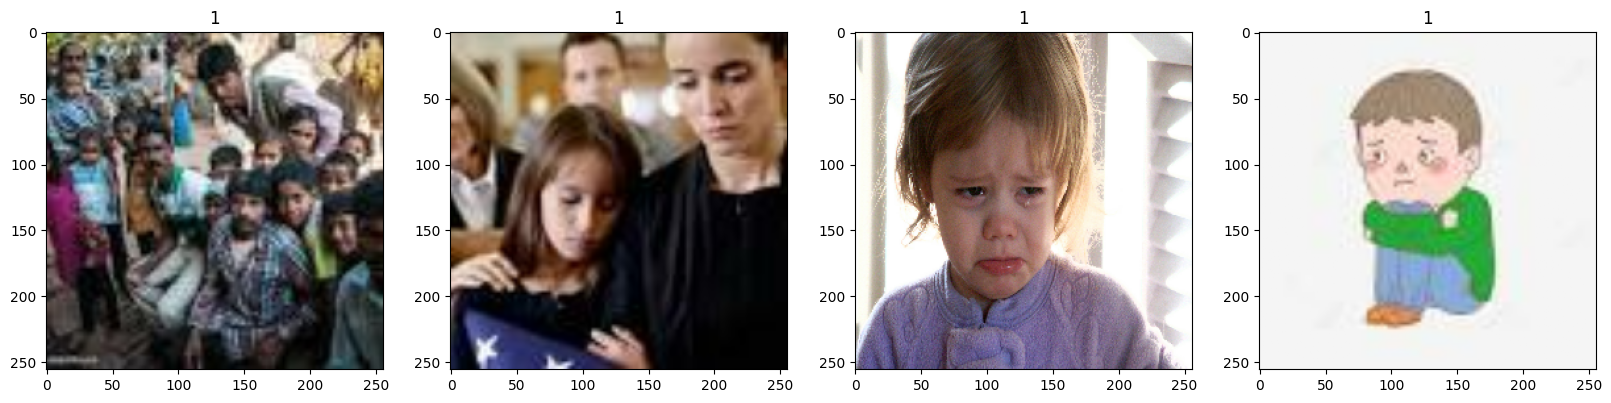

In [5]:
# Plot 4 images and find what label for each class
fig,ax=plt.subplots(ncols=4,figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

# 1 - sad 
# 0 - happy

In [6]:
# total number of batches
total_batches=len(data)
print(f"Total number of batches in dataset: {len(data)} ")

#Find the train,test and validation batch size
train_size = int(total_batches * 0.7)
val_size = int(total_batches * 0.2)
test_size = total_batches - train_size - val_size
print(f"Train size: {train_size}\nValidation size: {val_size}\nTest size: {test_size} ")

# split into test,train and validation 
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)


Total number of batches in dataset: 10 
Train size: 7
Validation size: 2
Test size: 1 


In [7]:
# Build model
model=Sequential()
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())
model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# mention loss, optimizer
model.compile('adam',loss=tf.losses.BinaryCrossentropy(),metrics=['accuracy'])

# get model summary
model.summary()

C:\Users\lekal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 14400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       3,686,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Folder for training logs
logdir='data'

# Create TensorBoard callback
tensorboard_callback=tf.keras.callbacks.TensorBoard(log_dir=logdir)

# Train the model and record its performance
hist=model.fit(train,epochs=20,validation_data=val,callbacks=[tensorboard_callback])

C:\Users\lekal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 384ms/step - accuracy: 0.4911 - loss: 0.8008 - val_accuracy: 0.5781 - val_loss: 0.6580
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 367ms/step - accuracy: 0.6429 - loss: 0.6213 - val_accuracy: 0.5781 - val_loss: 0.7024
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 363ms/step - accuracy: 0.7768 - loss: 0.5172 - val_accuracy: 0.8906 - val_loss: 0.4142
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 370ms/step - accuracy: 0.8214 - loss: 0.4102 - val_accuracy: 0.8750 - val_loss: 0.2986
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 395ms/step - accuracy: 0.9286 - loss: 0.2886 - val_accuracy: 0.8594 - val_loss: 0.3361
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 355ms/step - accuracy: 0.8571 - loss: 0.3160 - val_accuracy: 0.8750 - val_loss: 0.2430
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 368ms/step - accuracy: 0.9375 - loss: 0.2146 - val_accuracy: 0.9688 - val_loss: 0.1518
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 348ms/step - accuracy: 0.9732 - loss: 0.1410 - val_accuracy: 0.9844 - val_loss:

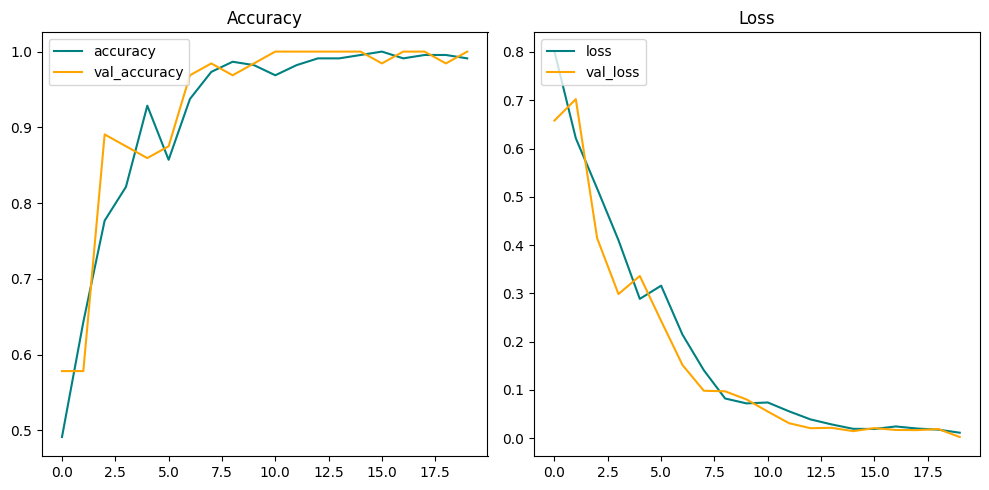

In [24]:
# performance
fig,ax=plt.subplots(ncols=2,figsize=(10,5))
ax[0].plot(hist.history['accuracy'],color='teal',label='accuracy')
ax[0].plot(hist.history['val_accuracy'],color='orange',label='val_accuracy')
ax[0].title.set_text('Accuracy')
ax[0].legend(loc='upper left')
ax[1].plot(hist.history['loss'],color='teal',label='loss')
ax[1].plot(hist.history['val_loss'],color='orange',label='val_loss')
ax[1].title.set_text("Loss")
ax[1].legend(loc="upper left")
plt.tight_layout()
plt.show()

In [28]:
pre=Precision()
re=Recall()
acc=BinaryAccuracy()

for batch in test.as_numpy_iterator():
    x,y=batch
    y_hat=model.predict(x)
    pre.update_state(y,y_hat)
    re.update_state(y,y_hat)
    acc.update_state(y,y_hat)
print(f"Precision: {pre.result()}\nRecall: {re.result()}\nAccuracy: {acc.result()} ")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Precision: 1.0
Recall: 1.0
Accuracy: 1.0 


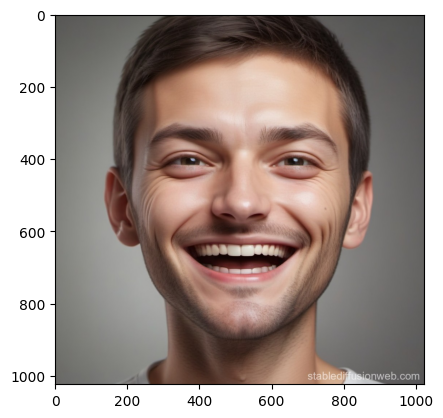

In [35]:
# Test the model
img=cv2.imread('data/a9a5f67e-9f1d-4016-a272-704305fda53a.jpg')
plt.imshow(img)
# convert image from BGR to RGB
img_RGB=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_RGB)
#plt.axis('off')
plt.show()

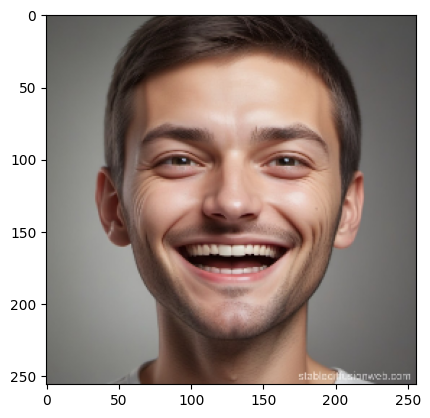

In [36]:
# resize the image and convert into numpy
resize=tf.image.resize(img_RGB,(256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [37]:

y_hat=model.predict(np.expand_dims(resize/255,0))
y_hat

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


array([[0.03382111]], dtype=float32)

In [39]:
if y_hat>0.5:
    print("Predicted class is SAD")
else:
    print("Predicted class is HAPPY")

Predicted class is HAPPY


In [41]:
# Save the model
model.save(os.path.join(data_dir,'Happy_sad_model.h5'))